# Эксперименты
**Обучение на сырых данных** 
- Score: $1965.98$

**Логарифмирование таргета**
- Score: $2079.75$
- Effect: $+113.78$
- Не будем использовать

**Понижение размерности с помощью численных фич PCA**
- Score: $1987.15$
- Effect: $+21.17$
- Не будем использовать

**Добавление кластерных фич**
- Score: $1967.68$
- Effect: $+1.7$
- Не будем использовать

**Генерация полиномиальных фич из числовых**
- Score: $1963.04$
- Effect: $-2.94$
- Используем

**Генерация парных категориальных фич**
- Score: $1953.07$
- Effect: $-9.97$ (Считая, что `PolyFeatures` Используется)
- Используем

**Использование целевой функции в качестве лосса**
- Score: $1986.98$
- Effect: $+21$
- Не будем использовать

**Удаление фичей, показавших меньший `importance`, чем случайные**
- Score: $1948.93$
- Effect: $-4.1$
- Используем

**Присвоение больших весов категориям объектов, на которых сильнее ошибается**
- Score: $2001.59$
- Effect: $+52.66$
- Не будем использовать

In [1]:
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from umap import UMAP

from matplotlib import pyplot as plt
from matplotlib.colors import Normalize

import seaborn as sns

import lightgbm as lgb

import warnings

warnings.filterwarnings("ignore")

# reproducibility
SEED = 7_961_377_73_42 % (1 << 32 - 1)
np.random.seed(SEED)

In [2]:
df_train = pd.read_csv("aim-2025-something-mysterious/train_contest.csv")
df_test = pd.read_csv("aim-2025-something-mysterious/test_contest.csv")
sample_submission = pd.read_csv("aim-2025-something-mysterious/sample_submission.csv")

df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=SEED)

x_train: pd.DataFrame = df_train.drop(columns=["target"])
y_train: pd.DataFrame = df_train["target"]
x_val: pd.DataFrame = df_val.drop(columns=["target"])
y_val: pd.DataFrame = df_val["target"]
x_test = df_test.drop(columns=["index"])

## Распределение таргетной фичи

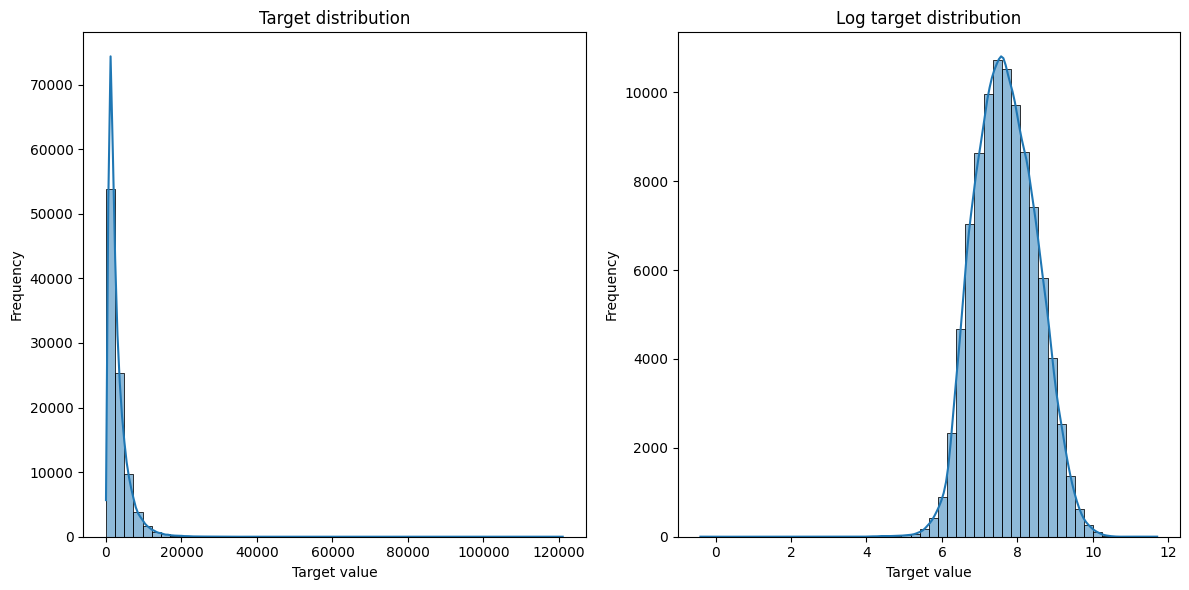

In [3]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

for i, target in enumerate([y_train, np.log(y_train)]):
    sns.histplot(target, bins=50, kde=True, ax=ax[i])
    ax[i].set_title("Target distribution" if i == 0 else "Log target distribution")
    ax[i].set_xlabel("Target value")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [4]:
# Закомментировано, так как не помогло
# y_train = np.log(y_train)
# y_val = np.log(y_val)

Из графиков видно, что распределение логарифма таргета похоже на нормальное, и имеет намного менее тяжёлый хвост, так что логарифмирование таргета может помочь.

Эмпирические эксперименты показали, что логарифмирование ухудшает качество, так что не будем делать это

## Препроцессинг

In [5]:
cat_features = df_train.select_dtypes(exclude=["number"]).columns.tolist()
num_features = df_train.select_dtypes(include=["number"]).columns.tolist()
num_features.remove("target")
all_features = cat_features + num_features

encoder = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            cat_features,
        ),
    ],
    remainder="passthrough",
)

x_train = pd.DataFrame(encoder.fit_transform(x_train), columns=x_train.columns)
x_val = pd.DataFrame(encoder.transform(x_val), columns=x_val.columns)
x_test = pd.DataFrame(encoder.transform(x_test), columns=x_test.columns)

x_train[cat_features] = x_train[cat_features].astype(np.int32)
x_val[cat_features] = x_val[cat_features].astype(np.int32)
x_test[cat_features] = x_test[cat_features].astype(np.int32)

## Понижение размерности (5 баллов)
Применим `UMAP` к численным фичам из обучающей выборки 

In [6]:
umap = UMAP(n_components=2, init="pca")
high_dim = x_train[num_features].values

embedding = umap.fit_transform(high_dim)
embedding_df = pd.DataFrame(embedding, columns=["x", "y"])

embedding_df["target"] = y_train.values

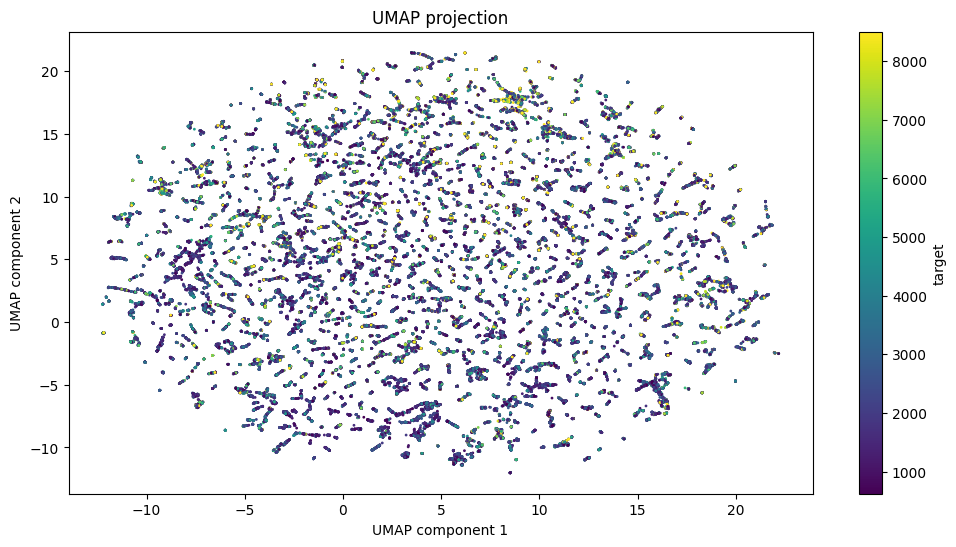

In [7]:

norm = Normalize(vmin=y_train.quantile(0.05), vmax=y_train.quantile(0.95))

plt.figure(figsize=(12, 6))
plt.scatter(
    embedding_df["x"],
    embedding_df["y"],
    c=embedding_df["target"],
    cmap="viridis",
    norm=norm,
    s=1,
)
plt.colorbar(label="target")
plt.title("UMAP projection")
plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.show()

Низкоразмерное представление данных почти не имеет какой-либо структуры, точки как будто равномерно распределены по шару. Наблюдаются мелкие кластеры, но их слишком много, так что вряд ли кластеризация существенно улучшит качество модели.

Для генерации фичей понижением размерности можно попробовать `PCA`

In [8]:
feats_to_decompose = num_features

pca = PCA(n_components=0.9)
pca.fit(x_train[feats_to_decompose])

# Скор ухудшился, так что закомментировано
# components_train = pd.DataFrame(pca.transform(x_train[num_features]), columns=pca.get_feature_names_out())
# components_val = pd.DataFrame(pca.transform(x_val[num_features]), columns=pca.get_feature_names_out())
# components_test = pd.DataFrame(pca.transform(x_test[num_features]), columns=pca.get_feature_names_out())

# num_features = components_train.columns.tolist()
# all_features = cat_features + num_features

# x_train = pd.concat([x_train, components_train], axis=1)
# x_val = pd.concat([x_val, components_val], axis=1)
# x_test = pd.concat([x_test, components_test], axis=1)

PCA(n_components=0.9)

## Кластеризация (5 баллов)
Из `UMAP`-эмбеддингов видно, что примеры распределены почти равномерно, но есть куча маленьких кластеров. Не будем делать настолько много кластеров, но попробуем добавить их как фичи

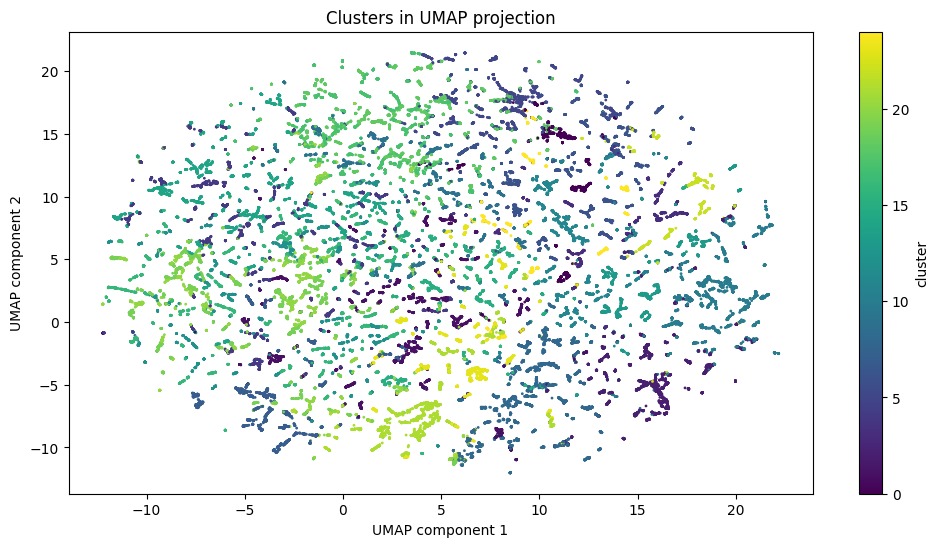

In [9]:
kmeans = KMeans(n_clusters=25, random_state=SEED)
kmeans.fit(x_train[num_features].values)

embedding_df["cluster"] = kmeans.labels_
plt.figure(figsize=(12, 6))
plt.scatter(
    embedding_df["x"],
    embedding_df["y"],
    c=embedding_df["cluster"],
    s=1,
)
plt.colorbar(label="cluster")
plt.title("Clusters in UMAP projection")
plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.show()

Как и ожидалось, кластеризация не помогла, так что не будем использовать её

In [10]:
# x_train["cluster"] = kmeans.predict(x_train[num_features].values)
# x_val["cluster"] = kmeans.predict(x_val[num_features].values)
# x_test["cluster"] = kmeans.predict(x_test[num_features].values)

# cat_features.append("cluster")
# all_features.append("cluster")

## Генерация фич (5 баллов)

У нас довольно много бинарных фич, которые, как будет видно чуть позже по ноутбуку, не так важны для модели по отдельности. Так как они могут обозначать вхождение в какие-либо категории, можно попробовать добавить фичу с числом таких вхождений. Как показывали эксперименты на валидиционной выборке, скор от этого улучшается

In [11]:
cat_features_nuniques = x_train[cat_features].nunique()
binary_features = cat_features_nuniques[cat_features_nuniques == 2].index.tolist()

name = "binary_cat_count"
x_train[name] = x_train[binary_features].sum(axis=1).astype(np.float32)
x_val[name] = x_val[binary_features].sum(axis=1).astype(np.float32)
x_test[name] = x_test[binary_features].sum(axis=1).astype(np.float32)

num_features.append(name)
all_features.append(name)

У нас не так много числовых фич, так что можно попробовать сгенерировать их сочетания с помощью `PolynomialFeatures`

In [12]:
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly.fit(x_train[num_features])

poly_features_train = poly.transform(x_train[num_features])
poly_features_val = poly.transform(x_val[num_features])
poly_features_test = poly.transform(x_test[num_features])

poly_feature_names = poly.get_feature_names_out(num_features).tolist()
poly_feature_names = list(map(lambda x: "_".join(x.split(" ")), poly_feature_names))

x_train[poly_feature_names] = poly_features_train
x_val[poly_feature_names] = poly_features_val
x_test[poly_feature_names] = poly_features_test

In [13]:
num_features = poly_feature_names
all_features = cat_features + num_features

Также можно попробовать сгенерировать парные категориальные фичи по аналогии с `PolynomialFeatures`. Для этого выберем 25 наименее разнообразных небинарных (потому что уже есть фича с их комбинацией) категориальных фичей и сгенерируем их комбинации

In [14]:
features_to_pair = (
    cat_features_nuniques.drop(binary_features).sort_values()[:25].index.tolist()
)


for feat1, feat2 in combinations(features_to_pair, 2):
    name = f"{feat1}_{feat2}"
    multiplier = cat_features_nuniques[feat2]
    x_train[name] = x_train[feat1] * multiplier + x_train[feat2]
    x_val[name] = x_val[feat1] * multiplier + x_val[feat2]
    x_test[name] = x_test[feat1] * multiplier + x_test[feat2]
    cat_features.append(name)
    all_features.append(name)

## Свои функции лосса и метрики (5 баллов)
Определим функцию лосса `loss_fn`, которая будет выдавать векторы градиентов и гессианов для каждого примера по предсказаниям, а также функцию метрики `metric_fn`, которая будет выдавать скор для более точной ранней остановки

In [15]:
def loss_fn(label: np.ndarray, pred: np.ndarray) -> float:
    eps = 100
    alpha = 1.2
    beta = 0.9

    grad = np.zeros_like(pred)
    hess = np.zeros_like(pred)

    mask = pred > label + eps
    grad[mask] = 2 * alpha * (pred[mask] - label[mask] - eps)
    hess[mask] = 2 * alpha

    mask = pred < label - eps
    grad[mask] = 2 * beta * (pred[mask] - label[mask] + eps)
    hess[mask] = 2 * beta

    return grad, hess


def metric_fn(label: np.ndarray, pred: np.ndarray) -> float:
    eps = 100
    alpha = 1.2
    beta = 0.9

    losses = np.zeros_like(pred)

    mask = pred > label + eps
    losses[mask] = alpha * (pred[mask] - label[mask] - eps) ** 2

    mask = pred < label - eps
    losses[mask] = beta * (pred[mask] - label[mask] + eps) ** 2

    return "assym_loss", np.sqrt(np.mean(losses)), False

Как показала практика, использование своих функций лосса и метрики не дало прироста качества, так что не будем использовать их в финальной модели

## Обучение модели

In [16]:
# Для исследования нерелевантных фич, добавим рандомные фичи
def add_random_features(df: pd.DataFrame, n: int) -> pd.DataFrame:
    for i in range(n):
        df[f"random_{i}"] = np.random.rand(len(df))
    return df


x_train = add_random_features(x_train, 5)
x_val = add_random_features(x_val, 5)
x_test = add_random_features(x_test, 5)

for i in range(5):
    num_features.append(f"random_{i}")
    all_features.append(f"random_{i}")

In [17]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    random_state=SEED,
    # objective=loss_fn, - скор ухудшился
)

model.fit(
    x_train[all_features],
    y_train,
    eval_set=[(x_val[all_features], y_val)],
    # eval_metric=metric_fn, - скор ухудшился
    eval_metric="rmse",
    categorical_feature=cat_features,
    callbacks=[
        lgb.log_evaluation(period=5),
        lgb.early_stopping(stopping_rounds=50, verbose=True),
    ],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.250126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36597
[LightGBM] [Info] Number of data points in the train set: 96075, number of used features: 539
[LightGBM] [Info] Start training from score 3039.278213
Training until validation scores don't improve for 50 rounds
[5]	valid_0's rmse: 2395.82	valid_0's l2: 5.73995e+06
[10]	valid_0's rmse: 2163.98	valid_0's l2: 4.68279e+06
[15]	valid_0's rmse: 2048.34	valid_0's l2: 4.19571e+06
[20]	valid_0's rmse: 1986.5	valid_0's l2: 3.9462e+06
[25]	valid_0's rmse: 1951.34	valid_0's l2: 3.80774e+06
[30]	valid_0's rmse: 1927.91	valid_0's l2: 3.71685e+06
[35]	valid_0's rmse: 1910.95	valid_0's l2: 3.65171e+06
[40]	valid_0's rmse: 1899.33	valid_0's l2: 3.60744e+06
[45]	valid_0's rmse: 1890.81	valid_0's l2: 3.57516e+06
[50]	valid_0's rmse: 1885.9	valid_0's l2: 3.5566e+06
[55]	valid_0's rmse: 1882.29	valid_0's l2: 3.54

LGBMRegressor(n_estimators=1000, random_state=156882366)

In [18]:
preds = model.predict(x_test[all_features])
# preds = np.exp(preds) - логарифмирование таргета не помогло
sample_submission["target"] = preds
sample_submission.to_csv("submission.csv", index=False)

## Интерпретация модели (5 баллов)
Посмотрим на значимость фичей в модели

In [19]:
model.importance_type = "split"
fi = pd.DataFrame(
    {
        "feature": model.feature_name_,
        "importance": model.feature_importances_,
    }
)
fi.sort_values("importance", ascending=False, inplace=True)
fi.reset_index(drop=True, inplace=True)
fi

,feature,importance
0,cat116,517
1,cat112,265
2,cat113,236
3,cont2_binary_cat_count,171
4,cont2_cont7,169
...,...,...
536,cat98_cat96,0
537,cat87_cat88,0
538,cat88_cat93,0
539,cat88_cat98,0


In [20]:
fi[fi["feature"].str.startswith("random_")]

,feature,importance
14,random_3,61
18,random_1,59
21,random_4,55
23,random_2,52
25,random_0,51


In [21]:
num_features_pruned = fi[
    (
        fi["importance"]
        >= fi[fi["feature"].str.startswith("random_")]["importance"].min()
    )  # только фичи с важностью больше минимальной рандомной
    & (fi["feature"].isin(num_features))  # только числовые фичи
    & (~fi["feature"].str.startswith("random_"))  # убираем рандомные
]["feature"].tolist()

all_features_pruned = cat_features + num_features_pruned

In [22]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    random_state=SEED,
    # objective=loss_fn, - скор ухудшился
)

model.fit(
    x_train[all_features_pruned],
    y_train,
    eval_set=[(x_val[all_features_pruned], y_val)],
    # eval_metric=metric_fn, - скор ухудшился
    eval_metric="rmse",
    categorical_feature=cat_features,
    callbacks=[
        lgb.log_evaluation(period=5),
        lgb.early_stopping(stopping_rounds=50, verbose=True),
    ],
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9436
[LightGBM] [Info] Number of data points in the train set: 96075, number of used features: 428
[LightGBM] [Info] Start training from score 3039.278213
Training until validation scores don't improve for 50 rounds
[5]	valid_0's rmse: 2394.4	valid_0's l2: 5.73315e+06
[10]	valid_0's rmse: 2162.78	valid_0's l2: 4.67761e+06
[15]	valid_0's rmse: 2049.62	valid_0's l2: 4.20094e+06
[20]	valid_0's rmse: 1987.22	valid_0's l2: 3.94906e+06
[25]	valid_0's rmse: 1951.91	valid_0's l2: 3.80995e+06
[30]	valid_0's rmse: 1928.67	valid_0's l2: 3.71978e+06
[35]	valid_0's rmse: 1912.66	valid_0's l2: 3.65827e+06
[40]	valid_0's rmse: 1903.99	valid_0's l2: 3.62518e+06
[45]	valid_0's rmse: 1896.57	valid_0's l2: 3.59698e+06
[50]	valid_0's rmse: 1892.17	valid_0

LGBMRegressor(n_estimators=1000, random_state=156882366)

In [23]:
preds = model.predict(x_test[all_features_pruned])
sample_submission["target"] = preds
sample_submission.to_csv("submission_pruned_features.csv", index=False)

Посмотрим на распределения ошибок по самым важным фичам

In [24]:
preds = model.predict(x_train[all_features_pruned])
x_train["pred"] = preds
x_train["abs_residual"] = np.abs(x_train["pred"] - y_train.values)

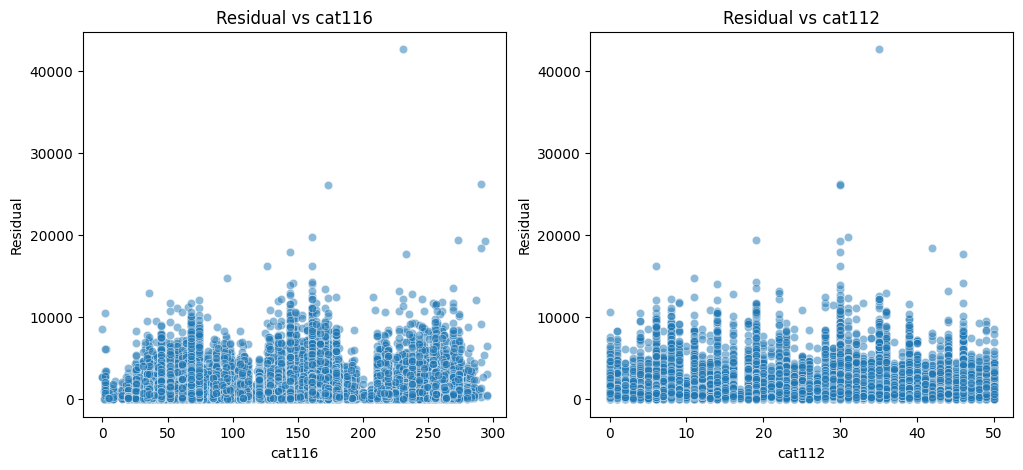

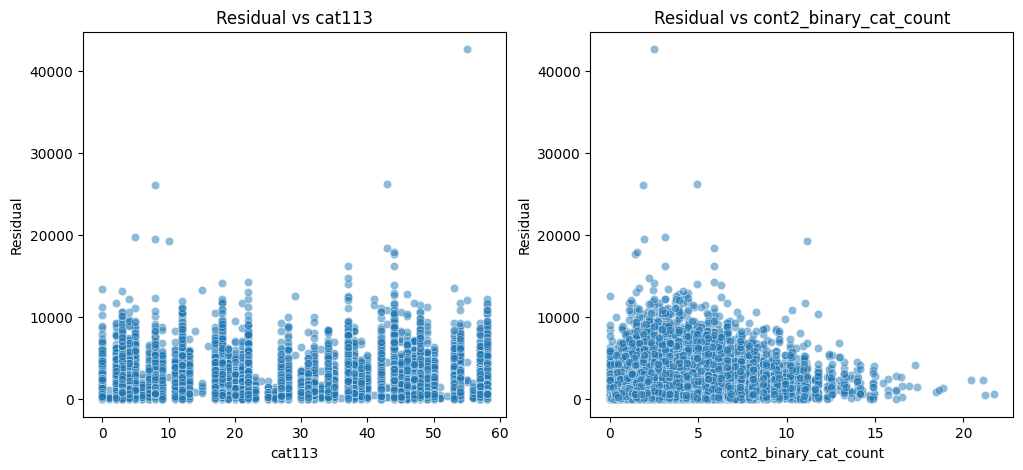

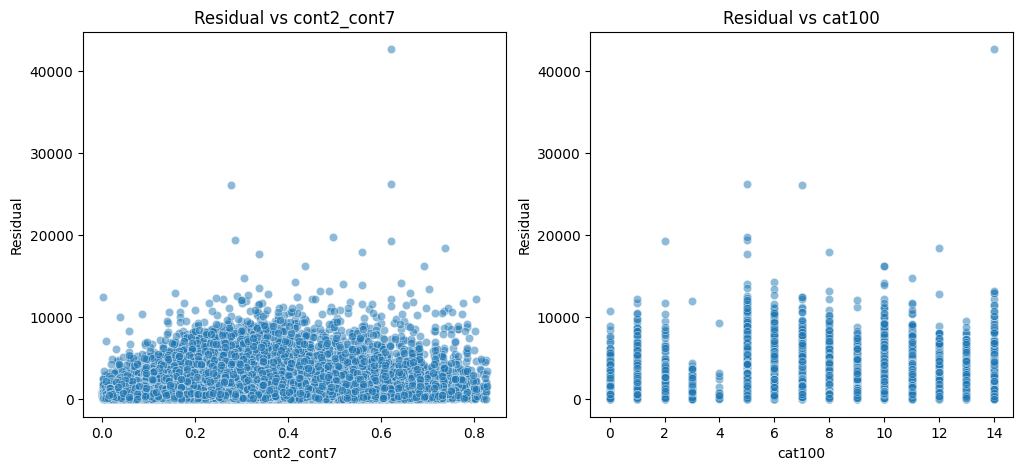

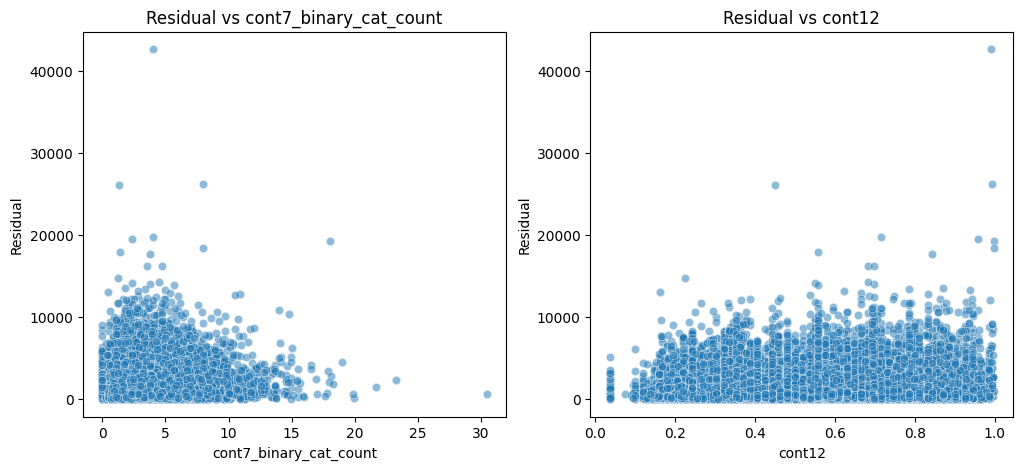

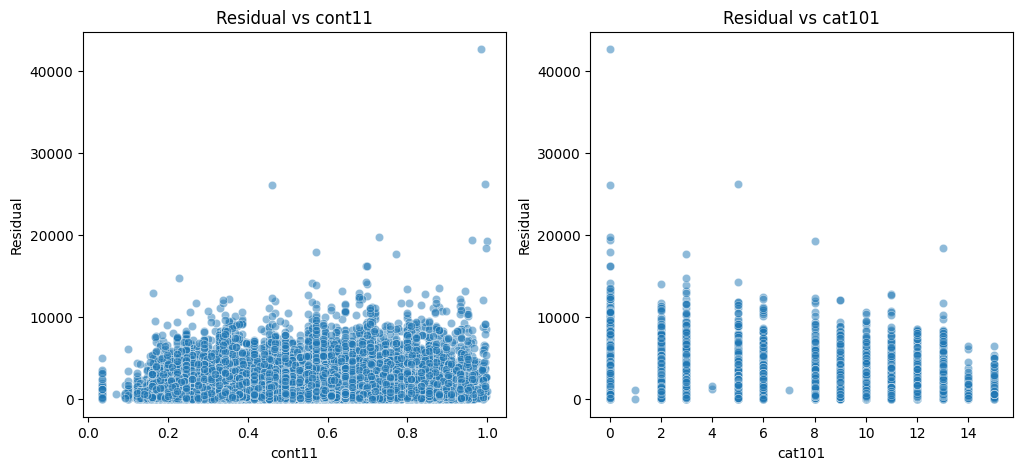

In [25]:
for i, feat in enumerate(fi.iloc[:10]["feature"]):
    if i % 2 == 0:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    sns.scatterplot(
        data=x_train,
        x=feat,
        y="abs_residual",
        alpha=0.5,
        ax=ax[i % 2],
    )
    ax[i % 2].set_title(f"Residual vs {feat}")
    ax[i % 2].set_xlabel(feat)
    ax[i % 2].set_ylabel("Residual")

    if i % 2 == 1:
        plt.show()
        plt.close()

Видно, что ошибки распределены неравномерно по категориям. Возможно, назначение больших весов на такие категории увеличит скор

In [26]:
features_to_weight = ["cat116", "cat112", "cat113", "cat100"]
mean_residual = x_train["abs_residual"].mean()

weights = {}
for feat in features_to_weight:
    weights[feat] = x_train.groupby(feat)["abs_residual"].mean() / mean_residual

train_weights = np.ones(len(x_train), dtype=np.float32)
val_weights = np.ones(len(x_val), dtype=np.float32)
for feat in features_to_weight:
    train_weights = train_weights * x_train[feat].map(weights[feat]).values
    val_weights = val_weights * x_val[feat].map(weights[feat]).values

np.nan_to_num(val_weights, copy=False, nan=1)
train_weights /= train_weights.mean()
val_weights /= val_weights.mean()

In [27]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    random_state=SEED,
)

model.fit(
    x_train[all_features_pruned],
    y_train,
    sample_weight=train_weights,
    eval_set=[(x_val[all_features_pruned], y_val)],
    # eval_sample_weight=[val_weights],
    eval_metric="rmse",
    categorical_feature=cat_features,
    callbacks=[
        lgb.log_evaluation(period=5),
        lgb.early_stopping(stopping_rounds=50, verbose=True),
    ],
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9436
[LightGBM] [Info] Number of data points in the train set: 96075, number of used features: 428
[LightGBM] [Info] Start training from score 3703.046783
Training until validation scores don't improve for 50 rounds
[5]	valid_0's rmse: 2431.43	valid_0's l2: 5.91186e+06
[10]	valid_0's rmse: 2186.19	valid_0's l2: 4.77943e+06
[15]	valid_0's rmse: 2067.92	valid_0's l2: 4.27629e+06
[20]	valid_0's rmse: 2012.56	valid_0's l2: 4.05039e+06
[25]	valid_0's rmse: 1981.96	valid_0's l2: 3.92818e+06
[30]	valid_0's rmse: 1960.17	valid_0's l2: 3.84227e+06
[35]	valid_0's rmse: 1947.62	valid_0's l2: 3.79323e+06
[40]	valid_0's rmse: 1935.41	valid_0's l2: 3.7458e+06
[45]	valid_0's rmse: 1927.48	valid_0's l2: 3.71519e+06
[50]	valid_0's rmse: 1922.65	valid_0

LGBMRegressor(n_estimators=1000, random_state=156882366)

In [28]:
# Скор ухудшился, так что не используем
# preds = model.predict(x_test[all_features_pruned])
# sample_submission["target"] = preds
# sample_submission.to_csv("submission.csv", index=False)